# Exploratory Data Analysis

O objetivo desta etapa é compreender as características da população de desenvolvimento, avaliar a qualidade dos dados e identificar padrões relevantes associados ao evento de inadimplência.

A análise servirá de base para as decisões de tratamento de dados e engenharia de variáveis realizadas nas próximas etapas.

## 1. Imports e Configurações

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
import numpy as np
import pickle

from src.eda import *

## 2. Dicionário de Tipos

Aqui serão definidos os tipos de cada variável afim de facilitar a manipulação nas etapas subsequentes.

In [2]:
tipos_var = {
    "key": [
        "id_cliente", 
        "safra_mes",
    ],
    "binary": [
        "ever_30",
        "ever_45",
        "ever_60",
        "ever_90",
        "sexo",
        "possui_carro",
        "possui_imovel",
    ],
    "categorical": [
        "ocupacao",
        "tipo_contrato_submissao",
        "dia_semana_solicitacao_submissao",
        "hora_solicitacao_submissao",
        "estado_civil",
        "tipo_renda",
        "tipo_organizacao",
        "tipo_moradia",
        "nivel_educacao",
    ],
    "integer": [
        "max_delay",
        "qtd_filhos",
        "qtd_membros_familia",
        "qtd_contratos_aceitos_historico",
        "qtd_contratos_recusados_historico",
        "nota_regiao_cliente",
        "nota_regiao_cliente_cidade",
    ],
    "numeric": [
        "valor_bem_submissao",
        "media_valor_credito_aceito_historico",
        "soma_valor_credito_ativo_historico",
        "valor_credito_submissao",
        "valor_parcela_submissao",
        "renda_anual",
    ],
    "datetime": [
        "data_solicitacao",
        "data_nascimento",
    ],
    "target": "target"
}

## 3. Carregamento das Bases

Nesta etapa serão carregadas as bases de Treino e Out of Time (OOT), garantindo a correta aplicação dos tipos de dados definidos no dicionário `tipos_var`.

Além da padronização dos tipos, será realizado um tratamento específico nas variáveis binárias que originalmente estão representadas por categorias textuais. Para adequação ao processo de modelagem, todas as variáveis binárias serão convertidas para formato numérico, seguindo as seguintes regras:

- `sexo`: `M` → `1` e `F` → `0`;
- `possui_carro`: `Y` → `1` e `N` → `0`;
- `possui_imovel`: `Y` → `1` e `N` → `0`.

Após a transformação, a variável `sexo` será renomeada para `sexo_masculino`, tornando sua interpretação mais clara e alinhada às boas práticas de modelagem. Os valores ausentes, quando existentes, serão preservados para tratamento posterior durante a etapa de imputação.

In [3]:
train_base = pd.read_parquet(
    "../data/processed/train_base.parquet"
)

oot_base = pd.read_parquet(
    "../data/processed/oot_base.parquet"
)

print(train_base.shape)
print(oot_base.shape)

(61912, 34)
(19970, 34)


In [4]:
train_base, tipos_var = prepare_dataset(
    train_base,
    tipos_var
)

train_base.head()

,id_cliente,data_solicitacao,dia_semana_solicitacao_submissao,hora_solicitacao_submissao,tipo_contrato_submissao,valor_credito_submissao,valor_bem_submissao,valor_parcela_submissao,data_nascimento,qtd_filhos,...,qtd_contratos_recusados_historico,soma_valor_credito_ativo_historico,media_valor_credito_aceito_historico,target,max_delay,ever_30,ever_45,ever_60,ever_90,sexo_masculino
0,100949,2020-01-18,SATURDAY,12,Consumer loans,96525.0,96525.0,10762.560,1987-03-09,1,...,0,178564.5,89282.25,0,-3,0,0,0,0,0
1,101032,2020-01-29,WEDNESDAY,13,Cash loans,92970.0,90000.0,18341.100,1966-11-09,0,...,1,462366.0,115591.50,0,-2,0,0,0,0,0
2,101294,2020-01-31,FRIDAY,15,Cash loans,164223.0,135000.0,18571.995,1980-07-14,0,...,0,236650.5,118325.25,0,-1,0,0,0,0,0
3,101684,2020-01-26,SUNDAY,14,Consumer loans,122773.5,115173.0,14851.035,1997-09-01,0,...,0,122773.5,122773.50,0,18,0,0,0,0,0
4,101813,2020-01-30,THURSDAY,12,Consumer loans,58702.5,60255.0,8007.030,1966-12-22,0,...,0,330255.0,110085.00,0,6,0,0,0,0,0


## 4. Visão Geral da Base

In [5]:
dataset_overview(train_base)

,dtype,missing,% missing,unique
ocupacao,string,20338,32.85,18
valor_bem_submissao,float64,1643,2.65,19278
data_solicitacao,datetime64[us],0,0.00,1461
id_cliente,string,0,0.00,30506
tipo_contrato_submissao,string,0,0.00,3
dia_semana_solicitacao_submissao,string,0,0.00,7
valor_credito_submissao,float64,0,0.00,25800
valor_parcela_submissao,float64,1,0.00,43453
data_nascimento,datetime64[us],0,0.00,13811
hora_solicitacao_submissao,string,0,0.00,24


## 5. Análise do Target

In [6]:
target_distribution(train_base)

,total,good,bad,% bad
0,61912,61403,509,0.82


In [7]:
target_by_safra(train_base)

,safra,total,bad,good,% bad
0,2020-01,630,24,606,3.81
1,2020-02,672,11,661,1.64
2,2020-03,707,19,688,2.69
3,2020-04,729,22,707,3.02
4,2020-05,739,11,728,1.49
5,2020-06,737,9,728,1.22
6,2020-07,672,8,664,1.19
7,2020-08,668,7,661,1.05
8,2020-09,773,9,764,1.16
9,2020-10,864,6,858,0.69


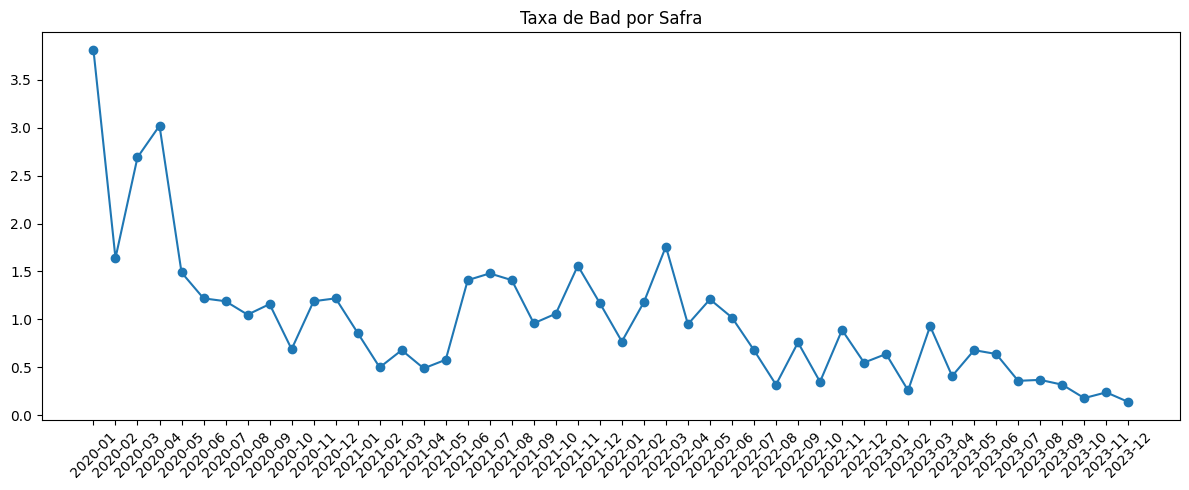

In [8]:
plot_target_by_safra(train_base)

## 6. Variáveis Derivadas

A variável `idade` pode ser construída pela diferença entre `data_solicitacao` - `data_nascimento`.

In [9]:
train_base, tipos_var = create_age_feature(
    train_base,
    tipos_var
)

display(tipos_var)

{'key': ['id_cliente', 'safra_mes'],
 'binary': ['ever_30',
  'ever_45',
  'ever_60',
  'ever_90',
  'possui_carro',
  'possui_imovel',
  'sexo_masculino'],
 'categorical': ['ocupacao',
  'tipo_contrato_submissao',
  'dia_semana_solicitacao_submissao',
  'hora_solicitacao_submissao',
  'estado_civil',
  'tipo_renda',
  'tipo_organizacao',
  'tipo_moradia',
  'nivel_educacao'],
 'integer': ['max_delay',
  'qtd_filhos',
  'qtd_membros_familia',
  'qtd_contratos_aceitos_historico',
  'qtd_contratos_recusados_historico',
  'nota_regiao_cliente',
  'nota_regiao_cliente_cidade',
  'idade'],
 'numeric': ['valor_bem_submissao',
  'media_valor_credito_aceito_historico',
  'soma_valor_credito_ativo_historico',
  'valor_credito_submissao',
  'valor_parcela_submissao',
  'renda_anual'],
 'datetime': [],
 'target': 'target'}

## 7. Qualidade dos Dados

### 7.1 Quantidade de Missings

Nesta etapa, realizamos o tratamento de valores nulos (missings) na base de dados, adotando uma regra clara de corte e imputação para garantir a qualidade do modelo:

* **Remoção de Variáveis (> 5% de nulos):** Variáveis que apresentam mais de 5% de dados faltantes serão completamente descartadas. A alta quantidade de nulos nessas colunas indica que a informação não é confiável ou abrangente o suficiente, e tentar preenchê-las poderia introduzir viés excessivo ou ruído ao modelo.
* **Imputação de Variáveis (≤ 5% de nulos):** Para as variáveis que possuem até 5% de valores ausentes, preservaremos a coluna e aplicaremos as seguintes estratégias de preenchimento (imputação):
  * **Variáveis Numéricas:** Os valores faltantes serão substituídos pela **média** da respectiva coluna.
  * **Variáveis Categóricas:** Os valores faltantes serão substituídos pela **moda** (valor mais frequente) da respectiva coluna.


In [10]:
missing_report(train_base)

,variable,missing,% missing
0,ocupacao,20338,32.85
1,valor_bem_submissao,1643,2.65
2,id_cliente,0,0.00
3,tipo_contrato_submissao,0,0.00
4,dia_semana_solicitacao_submissao,0,0.00
5,valor_credito_submissao,0,0.00
6,valor_parcela_submissao,1,0.00
7,qtd_filhos,0,0.00
8,hora_solicitacao_submissao,0,0.00
9,qtd_membros_familia,0,0.00


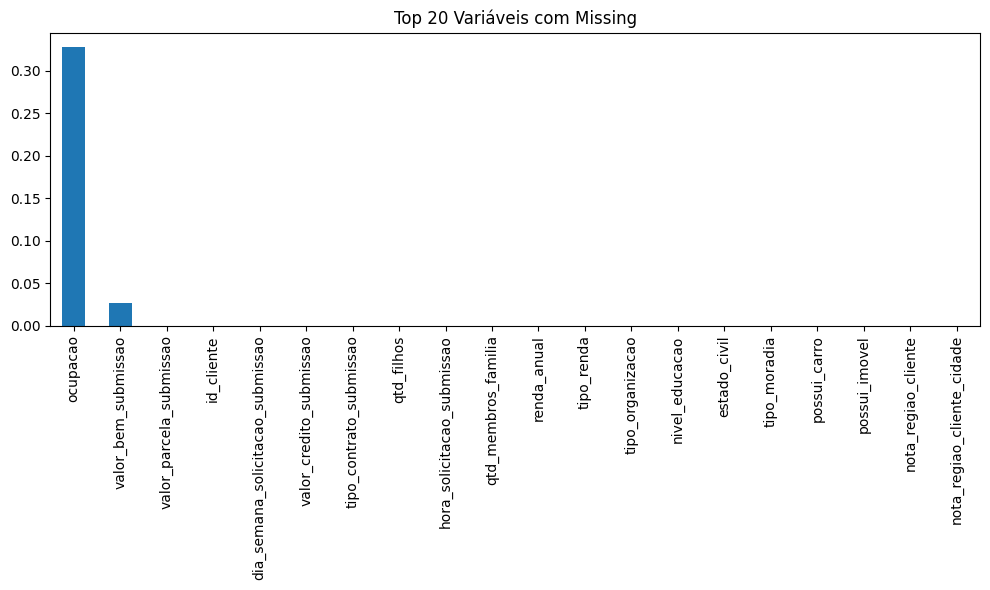

In [11]:
plot_missing(train_base)

### 7.2 Remoção de Variáveis

As variáveis abaixo foram utilizadas exclusivamente durante a construção e análise do target:

- max_delay
- ever_30
- ever_45
- ever_60
- ever_90

Como essas variáveis são derivadas diretamente do comportamento de inadimplência observado após a concessão do crédito, sua utilização na modelagem geraria vazamento de informação (target leakage). Dessa forma, elas serão removidas da base de modelagem.

A variável `ocupacao` apresentou elevado volume de valores ausentes, superior a 10% da população. Além disso, a análise exploratória não indicou evidências suficientes de que a informação remanescente compensaria o tratamento do volume de missing observado. Dessa forma, a variável será removida da modelagem.

In [12]:
vars_remover = [
    "max_delay",
    "ever_30",
    "ever_45",
    "ever_60",
    "ever_90",
    "ocupacao"
]

train_base, tipos_var = remove_variables(
    train_base,
    tipos_var,
    vars_remover
)

### 7.3 Dicionário de Imputação

Antes da aplicação da imputação, será construída uma tabela contendo os valores candidatos para preenchimento dos dados ausentes.

As regras adotadas serão:

- Variáveis `numeric`: imputação pela média.
- Variáveis `integer`: imputação pela média arredondada para número inteiro.
- Variáveis `binary`: imputação pela moda.
- Variáveis `categorical`: imputação pela moda.

Além de definir os valores de imputação, esta etapa permite documentar e rastrear todas as regras utilizadas, facilitando a reprodução do processo em ambientes de produção.

In [13]:
imputation_report, dicionario_imputacao = (
    build_imputation_dictionary(
        train_base,
        tipos_var
    )
)

display(imputation_report)

,variavel,tipo,media,mediana,moda,valor_imputacao
0,possui_carro,binary,<NA>,<NA>,0,0
1,possui_imovel,binary,<NA>,<NA>,1,1
2,sexo_masculino,binary,<NA>,<NA>,0,0
3,dia_semana_solicitacao_submissao,categorical,<NA>,<NA>,FRIDAY,FRIDAY
4,estado_civil,categorical,<NA>,<NA>,Married,Married
5,hora_solicitacao_submissao,categorical,<NA>,<NA>,11,11
6,nivel_educacao,categorical,<NA>,<NA>,Secondary / secondary special,Secondary / secondary special
7,tipo_contrato_submissao,categorical,<NA>,<NA>,Consumer loans,Consumer loans
8,tipo_moradia,categorical,<NA>,<NA>,House / apartment,House / apartment
9,tipo_organizacao,categorical,<NA>,<NA>,Business Entity Type 3,Business Entity Type 3


In [14]:
with open(
    r"G:\Meu Drive\Projetos\Github\cases\case_datarisk\outputs\dicts\dicionario_imputacao.pkl",
    "wb"
) as f:
    pickle.dump(
        dicionario_imputacao,
        f
    )

In [15]:
imputation_dictionary_to_df(
    dicionario_imputacao
)

,variavel,valor_imputacao
0,dia_semana_solicitacao_submissao,FRIDAY
1,estado_civil,Married
2,hora_solicitacao_submissao,11
3,idade,42
4,media_valor_credito_aceito_historico,157896.920831
5,nivel_educacao,Secondary / secondary special
6,nota_regiao_cliente,2
7,nota_regiao_cliente_cidade,2
8,possui_carro,0
9,possui_imovel,1


### 7.4 Imputação

Após a definição do dicionário de imputação, os valores ausentes serão tratados utilizando as regras estabelecidas no tópico anterior.

A imputação será aplicada de forma padronizada para todas as variáveis, garantindo consistência entre os ambientes de desenvolvimento, validação e produção.

Ao final do processo, será realizada uma nova avaliação de completude da base para confirmar que não existem valores ausentes remanescentes.

In [16]:
train_base = apply_imputation(
    train_base,
    dicionario_imputacao
)

missing_report(train_base)

Missings antes: 1,644
Missings depois: 0


,variable,missing,% missing
0,id_cliente,0,0.0
1,dia_semana_solicitacao_submissao,0,0.0
2,hora_solicitacao_submissao,0,0.0
3,tipo_contrato_submissao,0,0.0
4,valor_credito_submissao,0,0.0
5,valor_bem_submissao,0,0.0
6,valor_parcela_submissao,0,0.0
7,qtd_filhos,0,0.0
8,qtd_membros_familia,0,0.0
9,renda_anual,0,0.0


## 8. Análise Univariada

In [17]:
numeric_summary(
    train_base,
    tipos_var
)

,variable,count,mean,std,min,25%,50%,75%,max
0,idade,61912.0,41.911245,12.067232,18.0,32.0,41.0,52.0,68.0
1,media_valor_credito_aceito_historico,61912.0,157896.920831,158019.030248,7222.5,62934.75,109491.0,194923.245536,3524220.0
2,nota_regiao_cliente,61912.0,2.063445,0.501983,1.0,2.0,2.0,2.0,3.0
3,nota_regiao_cliente_cidade,61912.0,2.037359,0.494949,1.0,2.0,2.0,2.0,3.0
4,possui_carro,61912.0,0.341,0.474049,0.0,0.0,0.0,1.0,1.0
5,possui_imovel,61912.0,0.714805,0.451511,0.0,0.0,1.0,1.0,1.0
6,qtd_contratos_aceitos_historico,61912.0,2.832569,1.972663,1.0,1.0,2.0,4.0,22.0
7,qtd_contratos_recusados_historico,61912.0,0.456228,1.21061,0.0,0.0,0.0,0.0,31.0
8,qtd_filhos,61912.0,0.408887,0.71443,0.0,0.0,0.0,1.0,14.0
9,qtd_membros_familia,61912.0,2.158693,0.897663,1.0,2.0,2.0,3.0,15.0


In [18]:
categorical_summary(
    train_base,
    tipos_var
)

,variable,unique,missing,% missing,mode
0,dia_semana_solicitacao_submissao,7,0,0.0,FRIDAY
1,estado_civil,5,0,0.0,Married
2,hora_solicitacao_submissao,24,0,0.0,11
3,nivel_educacao,5,0,0.0,Secondary / secondary special
4,tipo_contrato_submissao,3,0,0.0,Consumer loans
5,tipo_moradia,6,0,0.0,House / apartment
6,tipo_organizacao,58,0,0.0,Business Entity Type 3
7,tipo_renda,7,0,0.0,Working


## 9. Relação entre Variáveis e Inadimplência

In [19]:
target_rate_report(
    train_base,
    tipos_var
)


possui_carro


,possui_carro,total,bad_rate
0,0,40800,0.85
1,1,21112,0.76



possui_imovel


,possui_imovel,total,bad_rate
0,0,17657,0.88
1,1,44255,0.80



sexo_masculino


...

,tipo_organizacao,total,bad_rate
36,Realtor,90,2.22
12,Hotel,231,2.16
38,Restaurant,371,1.89
43,Services,344,1.74
1,Agriculture,409,1.71
31,Military,479,1.67
20,Industry: type 3,615,1.63
45,Trade: type 1,68,1.47
16,Industry: type 11,520,1.35
54,Transport: type 3,234,1.28



tipo_moradia


,tipo_moradia,total,bad_rate
0,Co-op apartment,165,1.21
4,Rented apartment,901,1.00
5,With parents,2710,0.85
1,House / apartment,55451,0.82
3,Office apartment,442,0.68
2,Municipal apartment,2243,0.67



nivel_educacao


,nivel_educacao,total,bad_rate
0,Academic degree,29,3.45
3,Lower secondary,661,1.06
2,Incomplete higher,2132,0.98
4,Secondary / secondary special,45689,0.85
1,Higher education,13401,0.68


## 10. Tratamento de Domínio

### 10.1 Tratamento das Numéricas - Winsorização

Antes da modelagem, é importante avaliar a existência de valores extremos (outliers) nas variáveis numéricas.

Para as variáveis do tipo `numeric` e `integer`, será adotada uma abordagem de Winsorização baseada nos percentis 1% e 99%.

O objetivo não é remover observações, mas definir limites válidos para cada variável, reduzindo a influência de valores extremos que podem prejudicar a estabilidade dos modelos.

A variável `idade` será tratada como uma exceção, utilizando um domínio lógico de negócio entre 0 e 120 anos.

In [20]:
dominio_numerico, relatorio_numerico = build_numeric_domain(
    train_base,
    tipos_var
)

display(relatorio_numerico)

,variavel,limite_inferior,limite_superior,qtd_abaixo,%_abaixo,qtd_acima,%_acima
0,idade,0.00,120.00,0,0.00,0,0.00
1,media_valor_credito_aceito_historico,18416.23,744498.00,620,1.00,609,0.98
2,nota_regiao_cliente,1.00,3.00,0,0.00,0,0.00
3,nota_regiao_cliente_cidade,1.00,3.00,0,0.00,0,0.00
4,qtd_contratos_aceitos_historico,1.00,9.00,0,0.00,569,0.92
5,qtd_contratos_recusados_historico,0.00,5.00,0,0.00,609,0.98
6,qtd_filhos,0.00,3.00,0,0.00,98,0.16
7,qtd_membros_familia,1.00,5.00,0,0.00,96,0.16
8,renda_anual,49500.00,450000.00,561,0.91,596,0.96
9,soma_valor_credito_ativo_historico,19255.50,2963823.97,619,1.00,620,1.00


### 10.2 Tratamento das Categóricas

Para as variáveis categóricas, o domínio será definido pelos valores observados na base de treinamento.

Durante a aplicação do modelo, categorias não observadas anteriormente serão consideradas inválidas e substituídas pelo valor de imputação definido no dicionário de imputação.

In [21]:
dominio_categorico, relatorio_categorico = (
    build_categorical_domain(
        train_base,
        tipos_var
    )
)

display(relatorio_categorico)

,variavel,qtd_categorias
0,dia_semana_solicitacao_submissao,7
1,estado_civil,5
2,hora_solicitacao_submissao,24
3,nivel_educacao,5
4,tipo_contrato_submissao,3
5,tipo_moradia,6
6,tipo_organizacao,58
7,tipo_renda,7


In [22]:
dicionario_dominio = {
    "numerico": dominio_numerico,
    "categorico": dominio_categorico
}

with open(
    r"G:\Meu Drive\Projetos\Github\cases\case_datarisk\outputs\dicts\dicionario_dominio.pkl",
    "wb"
) as f:
    pickle.dump(
        dicionario_dominio,
        f
    )

### 10.3 Aplicação do Tratamento de Domínio

Nesta etapa os domínios definidos anteriormente serão aplicados à base de treinamento.

Valores numéricos fora dos limites permitidos serão considerados inválidos e substituídos pelos respectivos limites do domínio.

Valores categóricos não pertencentes ao conjunto de categorias válidas serão substituídos pela moda definida no dicionário de imputação.

Após a aplicação do tratamento, será realizada uma nova validação para garantir que não existam registros fora dos domínios estabelecidos.

In [23]:
train_base, fora_dominio_antes, fora_dominio_depois = apply_domain(
    train_base,
    dominio_numerico,
    dominio_categorico,
    dicionario_imputacao
)

display(fora_dominio_antes)
display(fora_dominio_depois)

,variavel,qtd_fora,%_fora
0,soma_valor_credito_ativo_historico,1239,2.00
1,media_valor_credito_aceito_historico,1229,1.99
2,valor_credito_submissao,1225,1.98
3,valor_bem_submissao,1223,1.98
4,renda_anual,1157,1.87
5,valor_parcela_submissao,1133,1.83
6,qtd_contratos_recusados_historico,609,0.98
7,qtd_contratos_aceitos_historico,569,0.92
8,qtd_filhos,98,0.16
9,qtd_membros_familia,96,0.16


,variavel,qtd_fora,%_fora
0,valor_bem_submissao,0,0.0
1,media_valor_credito_aceito_historico,0,0.0
2,soma_valor_credito_ativo_historico,0,0.0
3,valor_credito_submissao,0,0.0
4,valor_parcela_submissao,0,0.0
5,renda_anual,0,0.0
6,qtd_filhos,0,0.0
7,qtd_membros_familia,0,0.0
8,qtd_contratos_aceitos_historico,0,0.0
9,qtd_contratos_recusados_historico,0,0.0


## 11. Correlação entre Variáveis Numéricas

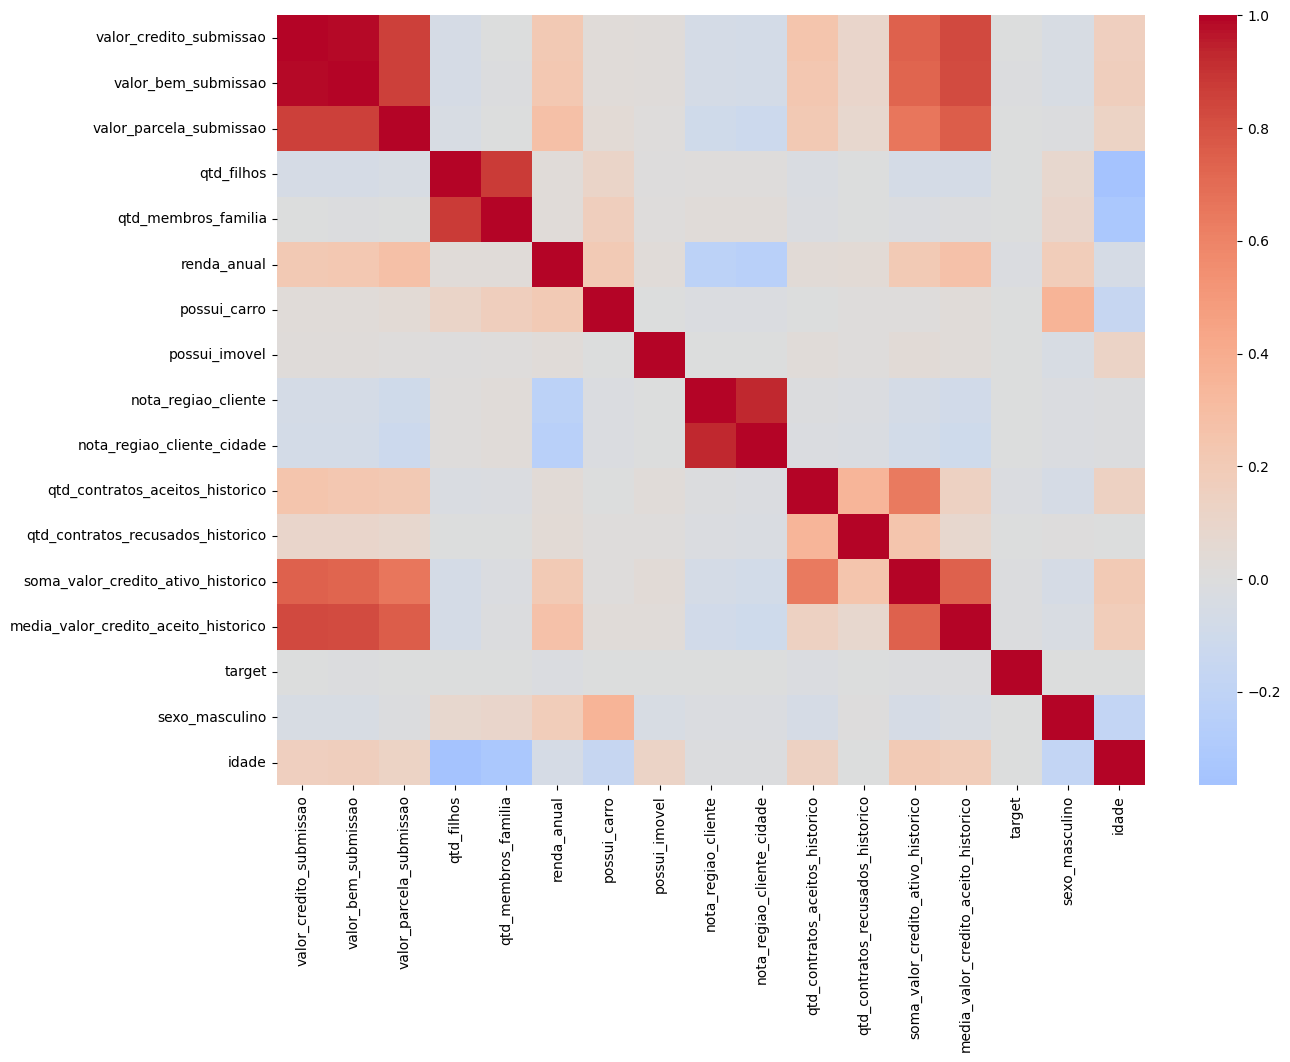

In [24]:
corr = correlation_matrix(train_base)

plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)
plt.show()

In [25]:
high_corr = get_high_correlations(
    corr,
    threshold=0.70
)

display(high_corr)

,variavel_1,variavel_2,correlacao
0,valor_credito_submissao,valor_bem_submissao,98.47
1,nota_regiao_cliente,nota_regiao_cliente_cidade,93.36
2,qtd_filhos,qtd_membros_familia,87.73
3,valor_bem_submissao,valor_parcela_submissao,85.77
4,valor_credito_submissao,valor_parcela_submissao,85.75
5,valor_credito_submissao,media_valor_credito_aceito_historico,83.00
6,valor_bem_submissao,media_valor_credito_aceito_historico,81.96
7,valor_parcela_submissao,media_valor_credito_aceito_historico,76.44
8,soma_valor_credito_ativo_historico,media_valor_credito_aceito_historico,74.89
9,valor_credito_submissao,soma_valor_credito_ativo_historico,74.17


## 12. Weight of Evidence (WOE)

Nesta etapa as variáveis categóricas serão transformadas utilizando a técnica de Weight of Evidence (WOE).

O WOE converte categorias em valores numéricos baseados na relação entre bons e maus pagadores observados na base de treinamento, preservando a capacidade preditiva das variáveis e tornando-as compatíveis com modelos estatísticos.

Após a transformação, as variáveis categóricas originais serão removidas e substituídas por suas respectivas versões com sufixo `_woe`.

In [26]:
woe_dictionary, woe_report = (
    build_woe_dictionary(
        train_base,
        tipos_var
    )
)

display(woe_report)

,variavel,categoria,total,good,bad,woe
0,dia_semana_solicitacao_submissao,SATURDAY,9375,9315,60,0.244999
1,dia_semana_solicitacao_submissao,SUNDAY,7043,6995,48,0.179666
2,dia_semana_solicitacao_submissao,MONDAY,8998,8934,64,0.139218
3,dia_semana_solicitacao_submissao,TUESDAY,8987,8910,77,-0.047085
4,dia_semana_solicitacao_submissao,WEDNESDAY,9083,8999,84,-0.123619
...,...,...,...,...,...,...
110,tipo_renda,Working,31306,31050,256,0.004449
111,tipo_renda,Pensioner,12240,12119,121,-0.189136
112,tipo_renda,Maternity leave,4,4,0,-2.594568
113,tipo_renda,Student,2,2,0,-3.182354


In [27]:
with open(
    r"G:\Meu Drive\Projetos\Github\cases\case_datarisk\outputs\dicts\woe_dictionary.pkl",
    "wb"
) as f:
    pickle.dump(
        woe_dictionary,
        f
    )

In [28]:
train_base, tipos_var = (
    apply_woe(
        train_base,
        tipos_var,
        woe_dictionary
    )
)

display(tipos_var)

{'key': ['id_cliente', 'safra_mes'],
 'binary': ['possui_carro', 'possui_imovel', 'sexo_masculino'],
 'categorical': [],
 'integer': ['qtd_filhos',
  'qtd_membros_familia',
  'qtd_contratos_aceitos_historico',
  'qtd_contratos_recusados_historico',
  'nota_regiao_cliente',
  'nota_regiao_cliente_cidade',
  'idade'],
 'numeric': ['valor_bem_submissao',
  'media_valor_credito_aceito_historico',
  'soma_valor_credito_ativo_historico',
  'valor_credito_submissao',
  'valor_parcela_submissao',
  'renda_anual',
  'tipo_contrato_submissao_woe',
  'dia_semana_solicitacao_submissao_woe',
  'hora_solicitacao_submissao_woe',
  'estado_civil_woe',
  'tipo_renda_woe',
  'tipo_organizacao_woe',
  'tipo_moradia_woe',
  'nivel_educacao_woe'],
 'datetime': [],
 'target': 'target'}

## 13. Normalização

Após a transformação WOE, todas as variáveis numéricas serão normalizadas utilizando Min-Max Scaling.

O procedimento transforma os valores para o intervalo [0,1], preservando a ordenação original dos dados e facilitando a utilização por algoritmos sensíveis à escala das variáveis.

In [29]:
normalization_dictionary, normalization_report = (
    build_normalization_dictionary(
        train_base,
        tipos_var
    )
)

display(normalization_report)

,variavel,min,max
0,valor_bem_submissao,17193.960000,1.260000e+06
1,media_valor_credito_aceito_historico,18416.227500,7.444980e+05
2,soma_valor_credito_ativo_historico,19255.500000,2.963824e+06
3,valor_credito_submissao,16245.495000,1.345311e+06
4,valor_parcela_submissao,2250.000000,7.067314e+04
5,renda_anual,49500.000000,4.500000e+05
6,tipo_contrato_submissao_woe,-0.125784,9.430647e-02
7,dia_semana_solicitacao_submissao_woe,-0.175541,2.449993e-01
8,hora_solicitacao_submissao_woe,-2.594568,1.258727e+00
9,estado_civil_woe,-0.317481,2.847836e-01


In [30]:
with open(
    r"G:\Meu Drive\Projetos\Github\cases\case_datarisk\outputs\dicts\normalization_dictionary.pkl",
    "wb"
) as f:
    pickle.dump(
        normalization_dictionary,
        f
    )

In [31]:
train_base = (
    apply_normalization(
        train_base,
        tipos_var,
        normalization_dictionary
    )
)

In [32]:
numeric_summary(
    train_base,
    tipos_var
)

,variable,count,mean,std,min,25%,50%,75%,max
0,dia_semana_solicitacao_submissao_woe,61912.0,0.43272,0.379222,0.0,0.091186,0.305455,0.844645,1.0
1,estado_civil_woe,61912.0,0.539191,0.246386,0.0,0.261775,0.650276,0.650276,1.0
2,hora_solicitacao_submissao_woe,61912.0,0.672173,0.050382,0.0,0.644009,0.681068,0.691805,1.0
3,idade,61912.0,0.478225,0.241345,0.0,0.28,0.46,0.68,1.0
4,media_valor_credito_aceito_historico,61912.0,0.188185,0.19141,0.0,0.061313,0.125433,0.243095,1.0
5,nivel_educacao_woe,61912.0,0.909082,0.055459,0.0,0.890073,0.890073,0.890073,1.0
6,nota_regiao_cliente,61912.0,0.531722,0.250992,0.0,0.5,0.5,0.5,1.0
7,nota_regiao_cliente_cidade,61912.0,0.51868,0.247474,0.0,0.5,0.5,0.5,1.0
8,possui_carro,61912.0,0.341,0.474049,0.0,0.0,0.0,1.0,1.0
9,possui_imovel,61912.0,0.714805,0.451511,0.0,0.0,1.0,1.0,1.0


In [33]:
with open(
    r"G:\Meu Drive\Projetos\Github\cases\case_datarisk\outputs\dicts\tipos_var.pkl",
    "wb"
) as f:
    pickle.dump(
        tipos_var,
        f
    )

## 14. Information Value (IV)

Após o cálculo do Weight of Evidence (WOE), será avaliado o poder preditivo individual das variáveis através do Information Value (IV).

O IV mede a capacidade de uma variável em distinguir bons e maus pagadores. Quanto maior o valor do IV, maior tende a ser sua relevância para o modelo.

A classificação utilizada será:

| Faixa IV | Interpretação |
|-----------|-----------|
| < 0.01 | Muito Fraco |
| 0.01 – 0.05 | Fraco |
| 0.05 – 0.15 | Moderado |
| 0.15 – 0.30 | Forte |
| > 0.30 | Muito Forte |

In [34]:
iv_report = calculate_information_value(
    train_base,
    tipos_var
)

display(iv_report)

,variavel,iv,classificacao
0,tipo_organizacao_woe,0.1292,Moderado
1,soma_valor_credito_ativo_historico,0.0583,Moderado
2,renda_anual,0.0544,Moderado
3,qtd_contratos_aceitos_historico,0.0442,Fraco
4,media_valor_credito_aceito_historico,0.0353,Fraco
5,valor_credito_submissao,0.0275,Fraco
6,valor_bem_submissao,0.0254,Fraco
7,dia_semana_solicitacao_submissao_woe,0.0245,Fraco
8,hora_solicitacao_submissao_woe,0.0223,Fraco
9,estado_civil_woe,0.0211,Fraco


## 15. Principais Insights

A análise exploratória permitiu compreender o comportamento da população, avaliar a qualidade dos dados e preparar a base para o desenvolvimento de modelos preditivos de risco de crédito.

**Qualidade dos Dados**

- Todas as variáveis tiveram seus tipos padronizados de acordo com o dicionário de tipos definido para o projeto.
- Variáveis binárias originalmente representadas por categorias textuais foram convertidas para formato numérico.
- Após a aplicação do dicionário de imputação, a base passou a possuir 100% de completude, sem valores ausentes.
- Foram removidas variáveis utilizadas na construção do target, eliminando potenciais riscos de vazamento de informação.

**Tratamento de Domínio**

- Foram identificados registros com valores fora dos domínios esperados para variáveis financeiras e históricas.
- O tratamento por Winsorização utilizando os percentis 1% e 99% permitiu reduzir a influência de valores extremos sem perda de observações.
- Após a aplicação das regras de domínio, todos os registros passaram a respeitar os limites estabelecidos.

**Correlação Entre Variáveis**

Foram identificadas correlações elevadas entre algumas variáveis, indicando possível redundância de informação:

- `valor_credito_submissao` e `valor_bem_submissao` (98,47%);
- `nota_regiao_cliente` e `nota_regiao_cliente_cidade` (93,36%);
- `qtd_filhos` e `qtd_membros_familia` (87,73%);
- `valor_bem_submissao` e `valor_parcela_submissao` (85,77%);
- `valor_credito_submissao` e `valor_parcela_submissao` (85,75%).

Esses pares deverão ser avaliados em etapas futuras de seleção de variáveis para reduzir multicolinearidade e simplificar o modelo.

**Transformação WOE**

- Todas as variáveis categóricas foram convertidas para Weight of Evidence (WOE).
- A transformação permitiu incorporar o comportamento histórico de inadimplência diretamente nas variáveis explicativas.
- Após a aplicação do WOE, não permaneceram variáveis categóricas na base analítica.

**Information Value (IV)**

A análise de Information Value permitiu identificar as variáveis com maior capacidade preditiva individual.

As variáveis mais relevantes foram:

| Variável | IV | Classificação |
|-----------|------:|-----------|
| tipo_organizacao_woe | 0,1292 | Moderado |
| soma_valor_credito_ativo_historico | 0,0583 | Moderado |
| renda_anual | 0,0544 | Moderado |

A maior parte das demais variáveis apresentou poder preditivo classificado como Fraco, indicando que o poder discriminatório do modelo deverá ser obtido principalmente pela combinação das variáveis e não por atributos isolados.

**Normalização**

- Todas as variáveis numéricas e inteiras foram normalizadas utilizando Min-Max Scaling.
- Após a transformação, as variáveis passaram a possuir escala padronizada entre 0 e 1.
- A normalização facilita a utilização por algoritmos sensíveis à escala e melhora a comparabilidade entre atributos.

**Preparação para Modelagem**

Ao final da EDA, todas as variáveis explicativas encontram-se:

- Tipadas e documentadas;
- Sem valores ausentes;
- Dentro dos domínios definidos;
- Transformadas em formato numérico;
- Normalizadas;
- Aptas para utilização nas etapas de seleção de variáveis e modelagem.

## 16. Conclusão

A etapa de Análise Exploratória de Dados (EDA) permitiu transformar a base bruta em um conjunto de dados consistente, documentado e preparado para o desenvolvimento de modelos de risco de crédito.

Durante o processo foram executadas atividades de padronização de tipos, criação de variáveis derivadas, tratamento de valores ausentes, definição de domínios de negócio, tratamento de outliers, análise de correlação, transformação WOE, cálculo de Information Value e normalização das variáveis.

A utilização de dicionários para tipagem, imputação, domínio, WOE e normalização tornou o processo totalmente reproduzível e aderente às boas práticas de modelagem estatística e implantação em produção.

Os principais resultados obtidos foram:

- Base final contendo 61.912 observações;
- Ausência de valores ausentes após imputação;
- Tratamento de outliers através de Winsorização;
- Remoção de variáveis relacionadas à definição do target;
- Conversão de todas as variáveis categóricas para Weight of Evidence (WOE);
- Normalização de todas as variáveis numéricas e inteiras utilizando Min-Max Scaling;
- Identificação de possíveis redundâncias através da análise de correlação;
- Avaliação do poder preditivo individual das variáveis através do Information Value (IV).

Entre os atributos avaliados, destacaram-se principalmente `tipo_organizacao_woe`, `soma_valor_credito_ativo_historico` e `renda_anual`, que apresentaram os maiores níveis de poder discriminatório individual.

Dessa forma, a base encontra-se preparada para as próximas etapas do projeto, incluindo seleção de variáveis, treinamento dos modelos estatísticos, avaliação de desempenho, análise de estabilidade e definição da estratégia de concessão de crédito.